## **Reading the data**

In [3]:
import pandas as pd
df = pd.read_csv("/content/introvert_extrovert_dataset.csv")
df

,Social_Interaction_Level,Talkativeness,Prefers_Alone_Time,Enjoys_Crowds,Friend_Count,Anxiety_Level,Decision_Making,Personality_Type
0,Medium,High,No,No,69,Low,Impulsive,Extrovert
1,High,Low,Yes,Yes,111,Low,Impulsive,Extrovert
2,High,Low,No,Yes,50,Low,Impulsive,Introvert
3,Low,High,No,Yes,167,Medium,Impulsive,Extrovert
4,Low,High,Yes,Yes,88,Low,Impulsive,Extrovert
...,...,...,...,...,...,...,...,...
95,Medium,Low,Yes,Yes,165,Medium,Impulsive,Introvert
96,Low,Low,Yes,Yes,5,High,Thoughtful,Extrovert
97,Medium,High,No,Yes,23,Low,Thoughtful,Extrovert
98,Medium,Medium,Yes,No,73,Low,Thoughtful,Introvert


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Social_Interaction_Level  100 non-null    object
 1   Talkativeness             100 non-null    object
 2   Prefers_Alone_Time        100 non-null    object
 3   Enjoys_Crowds             100 non-null    object
 4   Friend_Count              100 non-null    int64 
 5   Anxiety_Level             100 non-null    object
 6   Decision_Making           100 non-null    object
 7   Personality_Type          100 non-null    object
dtypes: int64(1), object(7)
memory usage: 6.4+ KB


In [5]:
df['Social_Interaction_Level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [6]:
df['Talkativeness'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [7]:
df['Prefers_Alone_Time'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
df['Enjoys_Crowds'].unique()

array(['No', 'Yes'], dtype=object)

In [9]:
df['Friend_Count'].unique()

array([ 69, 111,  50, 167,  88, 160,  10,  97,  72, 183,  54,   5,  22,
       103,  35,  86, 156, 138, 188, 199, 144,  73,  52,  40,  30, 132,
       126,  55, 174, 115, 172, 120, 164, 123,  84,   6, 121,  57, 194,
         8, 141,  49, 118, 159,  98,   3, 193, 108, 162, 145,  85, 124,
        61, 106, 171,   9,  77, 134,   2,  51,  90, 163,  38, 187, 200,
        67, 173, 176, 112,  82,  47, 175,  60, 177,  81, 143, 186, 180,
        46,  64, 110, 116, 165,  23, 133])

In [10]:
df['Anxiety_Level'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [11]:
df['Decision_Making'].unique()

array(['Impulsive', 'Thoughtful'], dtype=object)

In [12]:
df['Personality_Type'].unique()

array(['Extrovert', 'Introvert'], dtype=object)

## **Encoding the data**

In [16]:
df.replace({
    'Social_Interaction_Level' : {'Medium' :0, 'High':1, 'Low' :2},
    'Talkativeness' : {'High':0, 'Low':1, 'Medium':2},
    'Prefers_Alone_Time' :{'No' :0, 'Yes' :1},
    'Enjoys_Crowds' :{'No':0, 'Yes':1},
    'Anxiety_Level' :{'Low':0, 'Medium':1, 'High':2},
    'Decision_Making' : {'Impulsive':0, 'Thoughtful':1},
    'Personality_Type' : {'Extrovert':0, 'Introvert':1}

},inplace =True)

/tmp/ipython-input-16-2828946299.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [17]:
df

,Social_Interaction_Level,Talkativeness,Prefers_Alone_Time,Enjoys_Crowds,Friend_Count,Anxiety_Level,Decision_Making,Personality_Type
0,0,0,0,0,69,0,0,0
1,1,1,1,1,111,0,0,0
2,1,1,0,1,50,0,0,1
3,2,0,0,1,167,1,0,0
4,2,0,1,1,88,0,0,0
...,...,...,...,...,...,...,...,...
95,0,1,1,1,165,1,0,1
96,2,1,1,1,5,2,1,0
97,0,0,0,1,23,0,1,0
98,0,2,1,0,73,0,1,1


In [33]:
X = df.drop(['Personality_Type'],axis=1)
y = df['Personality_Type']

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [35]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
X_train

,Social_Interaction_Level,Talkativeness,Prefers_Alone_Time,Enjoys_Crowds,Friend_Count,Anxiety_Level,Decision_Making
11,1,1,0,0,5,0,0
47,1,2,0,0,3,0,1
85,2,2,0,1,143,1,0
28,1,2,1,1,55,0,0
93,0,0,1,1,110,2,1
...,...,...,...,...,...,...,...
60,2,0,1,1,9,1,0
71,0,0,1,0,200,0,1
14,2,1,0,0,35,0,0
92,1,0,0,0,120,0,1


In [38]:
model.score(X_train,y_train)

0.7

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score

a = accuracy_score(y_test,y_pred)
b = confusion_matrix(y_test,y_pred)
c = precision_score(y_test,y_pred)
d = recall_score(y_test,y_pred)

print("accuracy_score : ",a)
print("confusion_matrix : ",b)
print("precision_score : ",c)
print("recall_score : ",d)

accuracy_score :  0.5
confusion_matrix :  [[11  5]
 [10  4]]
precision_score :  0.4444444444444444
recall_score :  0.2857142857142857


## **Data Visualization**

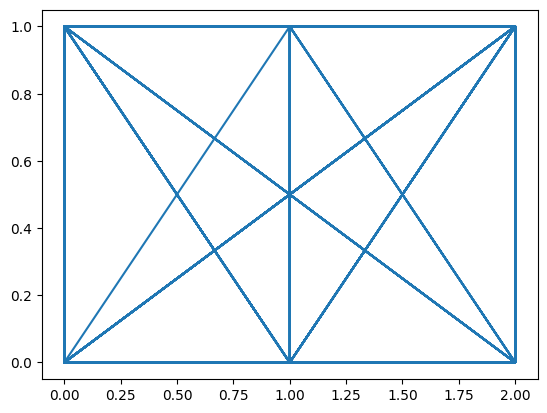

In [43]:
import matplotlib.pyplot as plt

plt.plot(df['Social_Interaction_Level'],df['Personality_Type'])
plt.show()

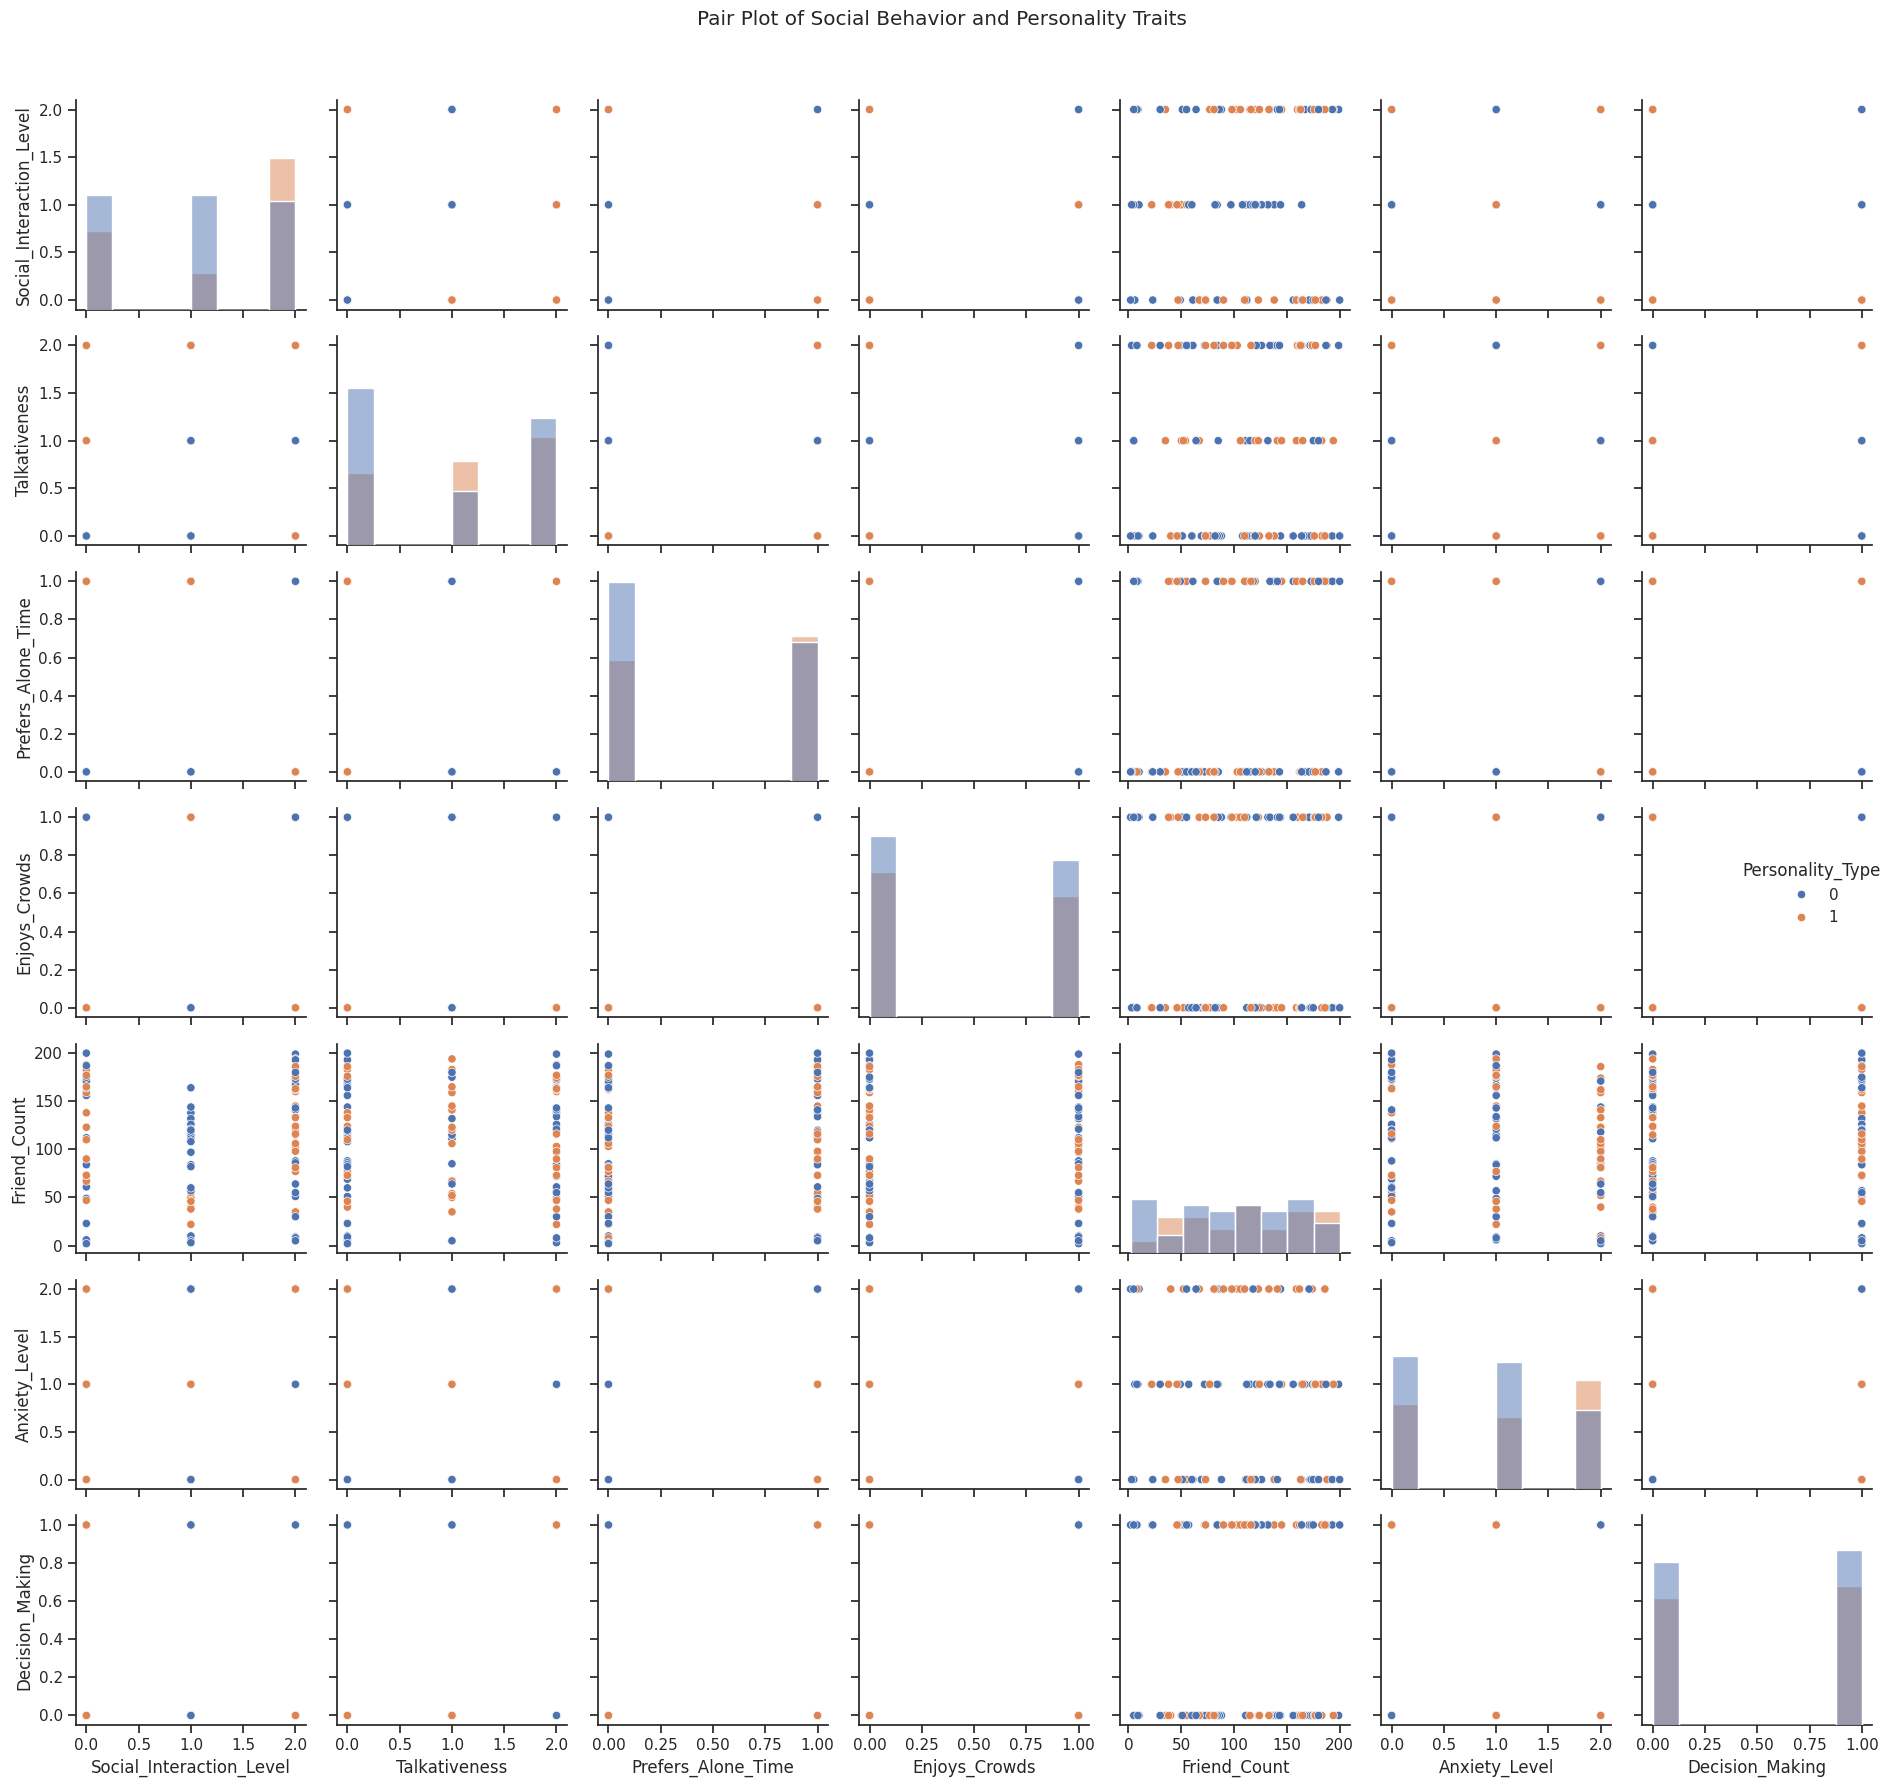

In [45]:
import seaborn as sns


# Encode categorical columns
df_encoded = df.copy()
for col in ['Social_Interaction_Level', 'Talkativeness', 'Prefers_Alone_Time',
            'Enjoys_Crowds', 'Anxiety_Level', 'Decision_Making', 'Personality_Type']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Plot pairplot
sns.set(style="ticks")
sns.pairplot(df_encoded, hue="Personality_Type", diag_kind="hist")
plt.suptitle("Pair Plot of Social Behavior and Personality Traits", y=1.02)
plt.tight_layout()
plt.show()


## **User Input**

In [51]:
#'Social_Interaction_Level', 'Talkativeness', 'Prefers_Alone_Time',
#            'Enjoys_Crowds', 'Anxiety_Level', 'Decision_Making',

'''   'Social_Interaction_Level' : {'Medium' :0, 'High':1, 'Low' :2},
    'Talkativeness' : {'High':0, 'Low':1, 'Medium':2},
    'Prefers_Alone_Time' :{'No' :0, 'Yes' :1},
    'Enjoys_Crowds' :{'No':0, 'Yes':1},
    'Anxiety_Level' :{'Low':0, 'Medium':1, 'High':2},
    'Decision_Making' : {'Impulsive':0, 'Thoughtful':1},
    'Personality_Type' : {'Extrovert':0, 'Introvert':1}
'''
name = input("Enter your good name please :  ")
Social_Interaction_Level = int(input( "Social_Interaction_Level : enter - {'Medium' :0, 'High':1, 'Low' :2}   : " ))
Talkativeness = int(input("Talkativeness  :enter - {'High':0, 'Low':1, 'Medium':2}   : "))
Prefers_Alone_Time = int(input(" Prefers_Alone_Time : enter - {'No' :0, 'Yes' :1}   : "))
Enjoys_Crowds = int(input(" Enjoys_Crowds  : enter - {'No' :0, 'Yes' :1}   : " ))
Friend_Count = int(input(" Friend_Count : Enter how many no of friends do you have : "))
Anxiety_Level = int(input("Anxiety_Level : enter - {'Low':0, 'Medium':1, 'High':2}   : "))
Decision_Making = int(input("Decision_Making : enter - {'Impulsive':0, 'Thoughtful':1}   : "))


user_input = [Social_Interaction_Level,Talkativeness,Prefers_Alone_Time,Enjoys_Crowds,Friend_Count,Anxiety_Level,Decision_Making]

y_pred = model.predict([user_input])

if y_pred == 0:
  print(name,"your are an Extrovert !!")
else :
  print(name,"your are an Introver")


Enter your good name please :  Vyshnavi
Social_Interaction_Level : enter - {'Medium' :0, 'High':1, 'Low' :2}   : 0
Talkativeness  :enter - {'High':0, 'Low':1, 'Medium':2}   : 2
 Prefers_Alone_Time : enter - {'No' :0, 'Yes' :1}   : 1
 Enjoys_Crowds  : enter - {'No' :0, 'Yes' :1}   : 0
 Friend_Count : Enter how many no of friends do you have : 17
Anxiety_Level : enter - {'Low':0, 'Medium':1, 'High':2}   : 1
Decision_Making : enter - {'Impulsive':0, 'Thoughtful':1}   : 0
Vyshnavi your are an Extrovert !!


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
